# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试答题模板

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

> 文件命名建议：`学号_姓名_期末考试.ipynb`

请在提交前从头到尾顺序运行一次 Notebook，确认所有代码无报错，图表和结果完整显示。

## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：物流管理
- 学号：852301520
- 姓名：陈嘉阳
- GitHub 仓库链接：
- 数据文件：'cars_jordan.csv'

# jordan车辆数据分析

## 1. 摘要

请用一段话概括本报告的主要内容，包括：

1. 本次分析关注了车身颜色、是否二手车、使用年限，不同价位等对车辆价格的影响。
2. 使用了哪些主要过异常值检测，数据质量分别和缺失值清除，t检验，一元线性回归，Pearson相关系数检验和箱型图，折线图等可视化方法。
3. 得到了首先是Opel Daewoo的性价比最高建议购买结论，其次是新车与旧车对价格影响显著，公里数与车辆价格负相关，大于5*5^10价位的车辆，其本身价值不受车身颜色、是否二手车、使用年限，不同价位等对车辆价格的影响。


## 2. 数据读取与分析目标

请说明本次分析的数据来源于老师爬虫所给的cars_jordan数据集
字段含义老师于Data Dictionary for JUCars Dataset已给，计划围绕二手车、使用年限，不同价位是否对价格是否产生影响展开分析。

## 3. 数据基本情况

请展示数据规模、字段名、数据类型、前几行样例，如结果所示
数据各列中存在大量缺失值，并且有重复行数。其中feat_battery_capacity字段缺失高达80.18，feat_battery_range缺失高达80.18，因此这两列数据不进行分析，同时出现多样复杂的字符类型，后续进行了相应的梳理与描述。

In [5]:
# 1. 导入所需的第三方核心库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 2. 配置matplotlib中文显示，防止中文乱码
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ===================== 二选一，使用绝对路径读取 =====================
# 方式1：CSV文件绝对路径（Windows系统，把路径替换成你自己文件真实路径）
try:
    df = pd.read_csv(r"D:\HuaweiMoveData\Users\11341\Desktop\无权限\数据分析与可视化考试\cars_jordan.csv", encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv(r"D:\HuaweiMoveData\Users\11341\Desktop\无权限\数据分析与可视化考试\cars_jordan.csv", encoding='gbk')

# 4. 查看数据的形状（总行数、总列数）
print("="*50)
print("===== 1. 数据形状统计 =====")
print(f"数据总行数：{df.shape[0]} 条，总列数：{df.shape[1]} 个")

# 4.2 查看数据的所有列名
print("\n" + "="*50)
print("===== 2. 数据列名清单 =====")
for index, col_name in enumerate(df.columns, 1):
    print(f"第{index}列：{col_name}")

# 4.3 查看数据的前10行样本
print("\n" + "="*50)
print("===== 3. 数据前10行预览 =====")
print(df.head(10))

# 4.4 查看数据的后5行样本
print("\n" + "="*50)
print("===== 4. 数据后5行预览 =====")
print(df.tail())

# 5. 查看每列的数据类型、非空值数量等详细信息
print("\n" + "="*50)
print("===== 5. 数据类型与非空值详情 =====")
df.info()

# 6. 统计每列的缺失值数量和缺失比例
print("\n" + "="*50)
print("===== 6. 每列缺失值统计 =====")
missing_value_count = df.isnull().sum()
missing_value_ratio = (df.isnull().sum() / len(df) * 100).round(2)
missing_stats_df = pd.DataFrame({
    '缺失值数量': missing_value_count,
    '缺失比例(%)': missing_value_ratio
})
print(missing_stats_df)

# 7. 检查数据中完全重复的行数量
print("\n" + "="*50)
print("===== 7. 重复行统计 =====")
duplicate_row_count = df.duplicated().sum()
print(f"数据中完全重复的行数：{duplicate_row_count} 条")

===== 1. 数据形状统计 =====
数据总行数：10921 条，总列数：22 个

===== 2. 数据列名清单 =====
第1列：price_value_JOD
第2列：make
第3列：model
第4列：year
第5列：mileage_km
第6列：mileage_text
第7列：body_type
第8列：condition
第9列：transmission
第10列：fuel_type
第11列：engine_type
第12列：color
第13列：interior_color
第14列：seats
第15列：city
第16列：feat_insurance
第17列：feat_carcustoms
第18列：feat_license
第19列：feat_paintcondition
第20列：feat_body_condition
第21列：feat_battery_capacity
第22列：feat_battery_range

===== 3. 数据前10行预览 =====
   price_value_JOD           make    model  year  mileage_km  \
0          13500.0          Honda   Accord  2017    154999.0   
1          22700.0  Mercedes Benz  C-Class  2016    134999.0   
2           4700.0          Mazda        2  2013    104999.0   
3          12700.0        Hyundai    Ioniq  2019     94999.0   
4          13700.0         Toyota  Corolla  2021     34999.0   
5          12750.0          Honda  Clarity  2018    134999.0   
6              NaN      Chevrolet     Bolt  2018    194999.0   
7           9400.0        

In [3]:
# 1. 导入所需的第三方核心库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 2. 配置matplotlib中文显示，防止中文乱码
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ===================== 二选一，使用绝对路径读取 =====================
# 方式1：CSV文件绝对路径（Windows系统，把路径替换成你自己文件真实路径）
try:
    df = pd.read_csv(r"D:\HuaweiMoveData\Users\11341\Desktop\无权限\数据分析与可视化考试\cars_jordan.csv", encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv(r"D:\HuaweiMoveData\Users\11341\Desktop\无权限\数据分析与可视化考试\cars_jordan.csv", encoding='gbk')

# ========== 需求1：用 df.dtypes 查看每列数据类型 ==========
print("="*60)
print("===== 1. 每列数据类型（df.dtypes） =====")
print(df.dtypes)

# ========== 需求2：用 df.describe(include='all') 查看全字段统计摘要 ==========
print("\n" + "="*60)
print("===== 2. 全字段统计摘要（df.describe(include='all')） =====")
print(df.describe(include='all'))

# ========== 需求3：查看指定6个字段的10行原始样例 ==========
print("\n" + "="*60)
print("===== 3. 指定字段原始样例（前10行） =====")
# 定义目标字段列表
target_cols = ["price_value_JOD", "make", "model", "year", "mileage_km", "mileage_text","body_type","condition","transmission","fuel_type","engine_type","color","interior_color","seats","city","feat_insurance"]
# 选取列并取前10行
sample_data = df[target_cols].head(10)
print(sample_data)

# ========== 需求4：计算每列缺失值数量与缺失比例（保留2位小数） ==========
print("\n" + "="*60)
print("===== 4. 每列缺失值数量与比例统计 =====")
# 计算每列缺失值数量
missing_count = df.isnull().sum()
# 计算缺失比例，保留2位小数
missing_ratio = (df.isnull().sum() / len(df) * 100).round(2)
# 合并为结果表格
missing_result = pd.DataFrame({
    "缺失值数量": missing_count,
    "缺失比例(%)": missing_ratio
})
print(missing_result)

# ========== 需求5：判断是否有重复行并统计数量 ==========
print("\n" + "="*60)
print("===== 5. 重复行检查结果 =====")
# 判断是否存在重复行
has_duplicate = df.duplicated().any()
# 统计重复行总数
duplicate_num = df.duplicated().sum()

if has_duplicate:
    print(f"数据中存在重复行，重复行总数：{duplicate_num} 条")
else:
    print("数据中不存在完全重复的行")

===== 1. 每列数据类型（df.dtypes） =====
price_value_JOD          float64
make                         str
model                        str
year                         str
mileage_km               float64
mileage_text                 str
body_type                    str
condition                    str
transmission                 str
fuel_type                    str
engine_type                  str
color                        str
interior_color               str
seats                        str
city                         str
feat_insurance               str
feat_carcustoms              str
feat_license                 str
feat_paintcondition          str
feat_body_condition          str
feat_battery_capacity        str
feat_battery_range           str
dtype: object

===== 2. 全字段统计摘要（df.describe(include='all')） =====
        price_value_JOD     make   model   year     mileage_km mileage_text  \
count      9.739000e+03    10285   10204  10284    8493.000000        10285   
unique           

# 5. 数据清洗与字段转换

请从原始文本字段开始清洗，例如处理单位、空格、换行符、混合格式等，再提取可分析的数值变量。

提示：本数据就不同于上次考试的部分，字段直接并未出现一列中存在两种不同类型的信息的情形，我通过对部分数值进行众数，平均数填补缺失值，NAN字节，或异常字符串转成空值，并且删除了重复列，防止数据集失真。

数据清洗，通过填充或修改·缺失值，异常值，删除重复行列，格式转换。

In [11]:
# ===================== 模块二：数据清洗（重复值与缺失值处理）修改版 =====================
# 1. 导入第三方核心库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 2. 配置matplotlib中文显示，防止中文乱码
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 3. 读取原始CSV数据，自动兼容utf-8和gbk两种编码
file_path = r"D:\HuaweiMoveData\Users\11341\Desktop\无权限\数据分析与可视化考试\cars_jordan.csv"
try:
    df_raw = pd.read_csv(file_path, encoding='utf-8')
except UnicodeDecodeError:
    df_raw = pd.read_csv(file_path, encoding='gbk')

# 打印清洗前基准数据形状，用于后续对比
print(f"清洗前数据形状：{df_raw.shape[0]} 行，{df_raw.shape[1]} 列")

# -----------------------------------------------------------------------------
# 步骤1：删除重复表头行
# 决策原因：多文件拼接/采集异常导致表头重复写入，属于无效脏数据，直接删除
# -----------------------------------------------------------------------------
# 筛选掉price_value_JOD列值为列名字符串的行，用copy生成独立副本避免链式赋值警告
df_clean = df_raw[df_raw['price_value_JOD'] != 'price_value_JOD'].copy()
print(f"删除重复表头后数据形状：{df_clean.shape[0]} 行，{df_clean.shape[1]} 列")

# -----------------------------------------------------------------------------
# 步骤2：删除完全重复的行
# 决策原因：完全重复行属于冗余数据，会干扰统计权重，保留第一条即可
# -----------------------------------------------------------------------------
dup_total = df_clean.duplicated().sum()
print(f"删除前完全重复行数：{dup_total} 条")
# 保留首次出现的行，重置索引保证序号连续
df_clean = df_clean.drop_duplicates(keep='first').reset_index(drop=True)
print(f"删除重复行后数据形状：{df_clean.shape[0]} 行，{df_clean.shape[1]} 列")

# -----------------------------------------------------------------------------
# 步骤3：处理 price_value_JOD 列缺失值（分层填充 + 剩余缺失删行）
# 决策原因：先按业务逻辑精细填充，最大限度保留数据；剩余少量缺失直接删行
# -----------------------------------------------------------------------------
# 先将价格列统一转为数值类型，异常字符串转为空值
df_clean['price_value_JOD'] = pd.to_numeric(df_clean['price_value_JOD'], errors='coerce')

# 第一轮填充：按「品牌+型号」分组的平均价格填充，同型号价格参考性最强
make_model_mean = df_clean.groupby(['make', 'model'])['price_value_JOD'].transform('mean')
df_clean['price_value_JOD'] = df_clean['price_value_JOD'].fillna(make_model_mean)

# 第二轮填充：仍缺失的行，用「品牌」维度的平均价格兜底
make_mean = df_clean.groupby('make')['price_value_JOD'].transform('mean')
df_clean['price_value_JOD'] = df_clean['price_value_JOD'].fillna(make_mean)

# 新增填充状态标记列，便于追溯数据来源
df_clean['price_fill_status'] = '原始值'
df_clean.loc[df_raw['price_value_JOD'].isnull(), 'price_fill_status'] = '分层填充'

# -----------------------------------------------------------------------------
# 步骤4：处理电池相关字段缺失值
# 决策原因：电池容量仅电动车有业务含义，燃油车缺失属于正常现象，统一标记为不适用
# -----------------------------------------------------------------------------
# 4.1 非电动车填充「Not Applicable」，区分“业务不适用”和“数据缺失”
non_electric_mask = df_clean['fuel_type'] != 'Electric'
df_clean.loc[non_electric_mask, 'feat_battery_capacity'] = df_clean.loc[non_electric_mask, 'feat_battery_capacity'].fillna('Not Applicable')
df_clean.loc[non_electric_mask, 'feat_battery_range'] = df_clean.loc[non_electric_mask, 'feat_battery_range'].fillna('Not Applicable')

# 4.2 电动车缺失值用同品牌众数填充（分类变量用众数比均值更贴合业务）
electric_mask = df_clean['fuel_type'] == 'Electric'
# 定义取众数的辅助函数，处理空众数情况
def get_mode(series):
    mode_res = series.mode()
    return mode_res.iloc[0] if len(mode_res) > 0 else np.nan

# 按品牌分组计算众数，填充电池容量和续航
brand_battery_mode = df_clean[electric_mask].groupby('make')['feat_battery_capacity'].transform(get_mode)
df_clean.loc[electric_mask, 'feat_battery_capacity'] = df_clean.loc[electric_mask, 'feat_battery_capacity'].fillna(brand_battery_mode)

brand_range_mode = df_clean[electric_mask].groupby('make')['feat_battery_range'].transform(get_mode)
df_clean.loc[electric_mask, 'feat_battery_range'] = df_clean.loc[electric_mask, 'feat_battery_range'].fillna(brand_range_mode)

# -----------------------------------------------------------------------------
# 步骤5：【按要求修改】删除所有仍包含缺失值的行
# 决策原因：用户明确允许剩余缺失直接删行，彻底消除空值，避免后续运算报错
# -----------------------------------------------------------------------------
before_drop = df_clean.shape[0]
# 删除任意列存在缺失的行
df_clean = df_clean.dropna(axis=0, how='any').reset_index(drop=True)
after_drop = df_clean.shape[0]
print(f"\n删除缺失行前：{before_drop} 条，删除后：{after_drop} 条，共删除 {before_drop - after_drop} 条含缺失值的行")

# -----------------------------------------------------------------------------
# 步骤6：输出清洗结果并保存文件
# -----------------------------------------------------------------------------
print("\n" + "="*60)
print("===== 清洗后数据总览 =====")
print(f"清洗后总行数：{df_clean.shape[0]} 条，总列数：{df_clean.shape[1]} 个")

print("\n===== 清洗后每列缺失值统计 =====")
missing_result = pd.DataFrame({
    '缺失值数量': df_clean.isnull().sum(),
    '缺失比例(%)': (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
})
print(missing_result)

# 保存清洗后的数据到源路径，utf-8-sig编码保证Excel打开不乱码
cleaned_save_path = r"D:\HuaweiMoveData\Users\11341\Desktop\无权限\数据分析与可视化考试\cars_jordan_cleaned.csv"
df_clean.to_csv(cleaned_save_path, index=False, encoding='utf-8-sig')
print(f"\n清洗后数据集已保存至：{cleaned_save_path}")

清洗前数据形状：10222 行，23 列
删除重复表头后数据形状：10222 行，23 列
删除前完全重复行数：0 条
删除重复行后数据形状：10222 行，23 列

删除缺失行前：10222 条，删除后：7254 条，共删除 2968 条含缺失值的行

===== 清洗后数据总览 =====
清洗后总行数：7254 条，总列数：23 个

===== 清洗后每列缺失值统计 =====
                       缺失值数量  缺失比例(%)
price_value_JOD            0      0.0
make                       0      0.0
model                      0      0.0
year                       0      0.0
mileage_km                 0      0.0
mileage_text               0      0.0
body_type                  0      0.0
condition                  0      0.0
transmission               0      0.0
fuel_type                  0      0.0
engine_type                0      0.0
color                      0      0.0
interior_color             0      0.0
seats                      0      0.0
city                       0      0.0
feat_insurance             0      0.0
feat_carcustoms            0      0.0
feat_license               0      0.0
feat_paintcondition        0      0.0
feat_body_condition        0      0.0
feat_b

In [15]:
# ===================== 模块三：类型转换与异常值处理（最终修复版）=====================
# 1. 导入第三方核心库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 2. 配置matplotlib中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 3. 读取模块二输出的清洗后数据
cleaned_path = r"D:\HuaweiMoveData\Users\11341\Desktop\无权限\数据分析与可视化考试\cars_jordan_cleaned.csv"
df = pd.read_csv(cleaned_path, encoding='utf-8-sig')
print(f"初始读取数据：{df.shape[0]} 行，{df.shape[1]} 列")

# -----------------------------------------------------------------------------
# 【关键修复步骤】字符串空值标准化 + 二次清洗
# 原因：CSV中字符串列的空值常以空字符串、空格、'nan'文本形式存在，isnull()检测不到
# 统一替换为标准NaN后再删行，彻底清除脏数据，避免后续类型转换报错
# -----------------------------------------------------------------------------
# 选中所有字符串类型的列
str_cols = df.select_dtypes(include='object').columns
# 将空字符串、纯空格、大小写nan/na统一替换为标准缺失值
df[str_cols] = df[str_cols].replace(['', ' ', 'nan', 'NaN', 'NA', 'null'], np.nan)
# 二次删除含缺失值的行，保证数据绝对干净
before = df.shape[0]
df = df.dropna().reset_index(drop=True)
after = df.shape[0]
print(f"二次清洗后数据：{after} 行，删除隐藏空值行 {before - after} 条")

# -----------------------------------------------------------------------------
# 步骤1：price_value_JOD 转换为 float 数值类型
# 决策原因：价格是核心数值指标，统一为浮点型支持后续统计与计算
# -----------------------------------------------------------------------------
df['price_value_JOD'] = pd.to_numeric(df['price_value_JOD'], errors='coerce')
print(f"\nprice_value_JOD 转换后类型：{df['price_value_JOD'].dtype}")

# -----------------------------------------------------------------------------
# 步骤2：year 列转换为整数类型
# 修复逻辑：先转浮点校验有效性，确认无NaN后再转原生int，避免IntCastingNaNError
# -----------------------------------------------------------------------------
# 先转为浮点型，无效值强制转NaN
year_float = pd.to_numeric(df['year'], errors='coerce')
# 过滤掉转换失败的行（极端情况兜底）
valid_mask = year_float.notna()
df = df[valid_mask].reset_index(drop=True)
year_float = year_float[valid_mask]
# 安全转为整数
df['year'] = year_float.astype(int)
print(f"year 转换后类型：{df['year'].dtype}，剩余有效行数：{len(df)}")

# -----------------------------------------------------------------------------
# 步骤3：mileage_km 列转换为数值类型
# 决策原因：里程是连续数值特征，统一为浮点型支持异常值校验
# -----------------------------------------------------------------------------
df['mileage_km'] = pd.to_numeric(df['mileage_km'], errors='coerce')
print(f"mileage_km 转换后类型：{df['mileage_km'].dtype}")

# -----------------------------------------------------------------------------
# 步骤4：从 mileage_text 提取里程中位数，生成 mileage_mid 数值列
# 决策原因：将文本区间转化为可量化的数值特征，兼容区间格式和单值格式
# -----------------------------------------------------------------------------
def calc_mileage_mid(text):
    """输入里程文本，返回区间中位数值"""
    if pd.isna(text):
        return np.nan
    # 移除逗号和空格，统一格式
    text_clean = str(text).replace(',', '').replace(' ', '')
    # 分割区间并计算平均值
    if '-' in text_clean:
        low_str, high_str = text_clean.split('-', 1)
        try:
            return (float(low_str) + float(high_str)) / 2
        except:
            return np.nan
    # 单个数值直接转换返回
    else:
        try:
            return float(text_clean)
        except:
            return np.nan

# 应用函数生成新列
df['mileage_mid'] = df['mileage_text'].apply(calc_mileage_mid)
print(f"\nmileage_mid 列已生成，样例预览：")
print(df[['mileage_text', 'mileage_mid']].head(8))

# -----------------------------------------------------------------------------
# 步骤5：异常值检查与标记（仅标记不删除，保留原始数据完整性）
# -----------------------------------------------------------------------------

# 5.1 价格异常值：IQR四分位距法识别
# 决策原因：二手车价格呈偏态分布，IQR法不受极端值影响；1.5倍IQR是通用异常阈值
df['is_price_outlier'] = False
price_valid = df['price_value_JOD'].dropna()
Q1 = price_valid.quantile(0.25)
Q3 = price_valid.quantile(0.75)
IQR = Q3 - Q1
lower_price = Q1 - 1.5 * IQR
upper_price = Q3 + 1.5 * IQR
# 增加合理性校验：价格不可能为负，低于0也标记为异常
df.loc[(df['price_value_JOD'] < lower_price) | (df['price_value_JOD'] > upper_price) | (df['price_value_JOD'] <= 0), 'is_price_outlier'] = True
print(f"\n【价格异常】共 {df['is_price_outlier'].sum()} 条，IQR正常区间：[{lower_price:.0f}, {upper_price:.0f}] JOD")

# 5.2 年份异常值：合理范围校验
# 决策原因：结合约旦二手车市场实际，1990年前车辆极少流通，2026年后属于未来年份，均为数据错误
df['is_year_outlier'] = False
df.loc[(df['year'] < 1990) | (df['year'] > 2026), 'is_year_outlier'] = True
print(f"【年份异常】共 {df['is_year_outlier'].sum()} 条，合理年份范围：1990 - 2026")

# 5.3 里程-年份匹配校验
# 修复说明：数据已彻底清洗无空值，temp_age全为有效整数，np.where不会再触发NA布尔歧义
# 决策原因：正常车辆年均里程有上限，按年均12.5万公里设定阈值，超出则大概率为录入错误
df['is_mileage_outlier'] = False
# 计算车龄（全为有效整数，无NA）
temp_age = 2026 - df['year']
# 当年新车（车龄≤0）里程上限设为5000公里，其余按年均12.5万公里计算
max_allowed_mileage = np.where(temp_age <= 0, 5000, temp_age * 125000)
# 标记里程超标的行
df.loc[df['mileage_km'] > max_allowed_mileage, 'is_mileage_outlier'] = True
print(f"【里程异常】共 {df['is_mileage_outlier'].sum()} 条（里程与车龄不匹配）")

# -----------------------------------------------------------------------------
# 步骤6：生成车龄列 car_age
# 决策原因：车龄是二手车折旧、估值分析的核心特征，以2026年为当前基准年计算
# -----------------------------------------------------------------------------
df['car_age'] = 2026 - df['year']
print(f"\n车龄列已生成，车龄分布统计：")
print(df['car_age'].describe().round(2))

# -----------------------------------------------------------------------------
# 步骤7：生成年均折旧价格 price_per_year
# 决策原因：年均折旧可横向对比不同车龄车辆的折旧水平；处理车龄为0的除零异常
# -----------------------------------------------------------------------------
# 车龄为0的当年新车，按1年折旧计算，直接取车价本身避免除以0报错
df['price_per_year'] = np.where(
    df['car_age'] <= 0,
    df['price_value_JOD'],
    df['price_value_JOD'] / df['car_age']
)
print(f"\n年均折旧列已生成，样例预览：")
print(df[['price_value_JOD', 'year', 'car_age', 'price_per_year']].head(8))

# -----------------------------------------------------------------------------
# 步骤8：保存最终处理结果
# -----------------------------------------------------------------------------
final_save_path = r"D:\HuaweiMoveData\Users\11341\Desktop\无权限\数据分析与可视化考试\cars_jordan_final.csv"
df.to_csv(final_save_path, index=False, encoding='utf-8-sig')

print("\n" + "="*60)
print(f"类型转换与异常值处理完成，最终数据形状：{df.shape[0]} 行，{df.shape[1]} 列")
print(f"最终数据集已保存至：{final_save_path}")

初始读取数据：7254 行，23 列
二次清洗后数据：7254 行，删除隐藏空值行 0 条

price_value_JOD 转换后类型：float64
year 转换后类型：float64，剩余有效行数：7253
mileage_km 转换后类型：float64

mileage_mid 列已生成，样例预览：
        mileage_text  mileage_mid
0  150,000 - 159,999     154999.5
1  130,000 - 139,999     134999.5
2  100,000 - 109,999     104999.5
3    90,000 - 99,999      94999.5
4    30,000 - 39,999      34999.5
5  130,000 - 139,999     134999.5
6  190,000 - 199,999     194999.5
7    90,000 - 99,999      94999.5

【价格异常】共 445 条，IQR正常区间：[-13550, 38050] JOD
【年份异常】共 48 条，合理年份范围：1990 - 2026
【里程异常】共 8 条（里程与车龄不匹配）

车龄列已生成，车龄分布统计：
count    7252.00
mean       10.05
std         7.80
min         0.00
25%         4.00
50%         8.00
75%        13.00
max        54.00
Name: car_age, dtype: float64

年均折旧列已生成，样例预览：
   price_value_JOD    year  car_age  price_per_year
0     13500.000000  2017.0      9.0     1500.000000
1     22700.000000  2016.0     10.0     2270.000000
2      4700.000000  2013.0     13.0      361.538462
3     12700.000000  2019.0      7.

C:\Users\11341\AppData\Local\Temp\ipykernel_26632\4243942465.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include='object').columns



类型转换与异常值处理完成，最终数据形状：7253 行，29 列
最终数据集已保存至：D:\HuaweiMoveData\Users\11341\Desktop\无权限\数据分析与可视化考试\cars_jordan_final.csv


## 6. 描述性统计分析

请使用 `pandas` / `numpy` 完成筛选、排序、分组、聚合、统计描述、透视表或交叉分析，并解释结果含义。
通过按照品牌，使用年限，价格、车身颜色，是否是汽油车，是否是电车分别进行了相应的描述性统计，主要关注方差，均值，中位数，众异系数等，得出的结论如统计说明所示

In [16]:
# ===================== 1. 导入核心依赖库 =====================
import numpy as np
import pandas as pd

# ===================== 2. 读取最终清洗后的数据集 =====================
# 读取路径与之前的代码保持一致，utf-8-sig编码保证中文正常显示
final_data_path = r"D:\HuaweiMoveData\Users\11341\Desktop\无权限\数据分析与可视化考试\cars_jordan_final.csv"
df = pd.read_csv(final_data_path, encoding='utf-8-sig')

# 先输出数据基本信息，确认列名与数据结构，避免后续统计对不存在的列操作
print("="*80)
print("===== 数据集基础信息校验 =====")
print(f"数据总行数：{df.shape[0]} 条，总列数：{df.shape[1]} 个")
print("\n数据列名清单：")
for idx, col in enumerate(df.columns, 1):
    print(f"{idx}. {col}")
print("="*80)
# ===================== 3. 所有数值列的描述性统计 =====================
# 需求：计算所有数值列的均值、中位数、标准差、四分位数、最值
print("\n" + "="*80)
print("===== 一、全量数值列描述性统计结果 =====")
print("="*80)

# 自动筛选出所有数值类型的列，避免非数值列参与统计报错
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(f"本次统计的数值列清单：{list(numeric_cols)}")
print("\n")

# 生成完整的描述性统计结果，包含均值、中位数、标准差、四分位数、最值等
numeric_desc = df[numeric_cols].describe().round(4)
# 补充中位数（describe默认50%分位数就是中位数，单独提取更清晰）
numeric_desc.loc['中位数'] = df[numeric_cols].median().round(4)
# 补充变异系数（标准差/均值，衡量数据离散程度）
numeric_desc.loc['变异系数'] = (df[numeric_cols].std() / df[numeric_cols].mean()).round(4)

# 输出统计结果
print(numeric_desc)
print("\n【统计说明】")
print("1. 均值：反映数据的平均水平；中位数：反映数据的中间水平，不受极端值影响")
print("2. 标准差/变异系数：反映数据的离散程度，值越大说明数据波动越大")
print("3. 四分位数：25%/50%/75%分位数，反映数据的分布区间")
print("4. 最值：反映数据的取值范围边界")
# ===================== 4. 按品牌（make）分组统计 =====================
# 需求：计算各品牌的平均价格、平均里程、平均车龄
print("\n" + "="*80)
print("===== 二、按品牌维度分组统计结果 =====")
print("="*80)

# 先校验核心列是否存在，不存在则跳过该模块统计
required_cols = ['make', 'price_value_JOD', 'mileage_km', 'car_age']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    print(f"【警告】缺失统计所需列：{missing_cols}，跳过品牌维度统计")
else:
    # 按品牌分组，计算指定指标的均值，保留2位小数
    brand_stats = df.groupby('make').agg(
        车辆总数=('make', 'count'),
        平均价格_JOD=('price_value_JOD', 'mean'),
        平均里程_km=('mileage_km', 'mean'),
        平均车龄_年=('car_age', 'mean')
    ).round(2)
    
    # 按车辆总数降序排序，优先展示保有量高的品牌
    brand_stats = brand_stats.sort_values('车辆总数', ascending=False)
    print(brand_stats)
    print("\n【统计说明】")
    print("1. 车辆总数：该品牌在数据集中的样本量，反映市场保有量")
    print("2. 平均价格：该品牌二手车的整体均价，反映品牌定位")
    print("3. 平均里程/车龄：反映该品牌二手车的使用强度")
    # ===================== 5. 按车身类型（body_type）分组统计 =====================
# 需求：计算各类型车辆的数量、平均价格
print("\n" + "="*80)
print("===== 三、按车身类型维度分组统计结果 =====")
print("="*80)

# 校验核心列是否存在
required_cols = ['body_type', 'price_value_JOD']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    print(f"【警告】缺失统计所需列：{missing_cols}，跳过车身类型维度统计")
else:
    # 按车身类型分组，计算数量和平均价格
    body_type_stats = df.groupby('body_type').agg(
        车辆总数=('body_type', 'count'),
        平均价格_JOD=('price_value_JOD', 'mean')
    ).round(2)
    
    # 按车辆总数降序排序
    body_type_stats = body_type_stats.sort_values('车辆总数', ascending=False)
    print(body_type_stats)
    print("\n【统计说明】")
    print("1. 车辆总数：该车身类型的市场占比，反映用户偏好")
    print("2. 平均价格：不同车身类型的价格差异，通常SUV/轿车价格差异明显")
    # ===================== 6. 按燃料类型（fuel_type）分组统计 =====================
# 需求：计算各类型车辆的数量、平均价格、平均里程
print("\n" + "="*80)
print("===== 四、按燃料类型维度分组统计结果 =====")
print("="*80)

# 校验核心列是否存在
required_cols = ['fuel_type', 'price_value_JOD', 'mileage_km']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    print(f"【警告】缺失统计所需列：{missing_cols}，跳过燃料类型维度统计")
else:
    # 按燃料类型分组，计算指定指标
    fuel_type_stats = df.groupby('fuel_type').agg(
        车辆总数=('fuel_type', 'count'),
        平均价格_JOD=('price_value_JOD', 'mean'),
        平均里程_km=('mileage_km', 'mean')
    ).round(2)
    
    # 按车辆总数降序排序
    fuel_type_stats = fuel_type_stats.sort_values('车辆总数', ascending=False)
    print(fuel_type_stats)
    print("\n【统计说明】")
    print("1. 车辆总数：不同燃料类型的市场占比，反映当地能源偏好")
    print("2. 平均价格：新能源/燃油车的价格差异，通常电动车均价更高")
    print("3. 平均里程：不同燃料类型车辆的使用强度差异")
    # ===================== 7. 按车身状况（feat_body_condition）分组统计 =====================
# 需求：查看不同车况下的平均价格差异
print("\n" + "="*80)
print("===== 五、按车身状况维度分组统计结果 =====")
print("="*80)

# 校验核心列是否存在
required_cols = ['feat_body_condition', 'price_value_JOD']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    print(f"【警告】缺失统计所需列：{missing_cols}，跳过车身状况维度统计")
else:
    # 按车身状况分组，计算车辆数量和平均价格
    body_condition_stats = df.groupby('feat_body_condition').agg(
        车辆总数=('feat_body_condition', 'count'),
        平均价格_JOD=('price_value_JOD', 'mean')
    ).round(2)
    
    # 按平均价格降序排序，直观展示车况与价格的正相关关系
    body_condition_stats = body_condition_stats.sort_values('平均价格_JOD', ascending=False)
    print(body_condition_stats)
    print("\n【统计说明】")
    print("1. 车辆总数：不同车况的样本分布")
    print("2. 平均价格：车况与价格的正相关关系，车况越好均价越高")
    # ===================== 8. 品牌-车身类型价格透视表 =====================
# 需求：行=品牌，列=车身类型，值=平均价格
print("\n" + "="*80)
print("===== 六、品牌-车身类型平均价格透视表 =====")
print("="*80)

# 校验核心列是否存在
required_cols = ['make', 'body_type', 'price_value_JOD']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    print(f"【警告】缺失统计所需列：{missing_cols}，跳过透视表生成")
else:
    # 生成透视表，行=品牌，列=车身类型，值=平均价格，空值填充为0
    price_pivot = pd.pivot_table(
        df,
        index='make',
        columns='body_type',
        values='price_value_JOD',
        aggfunc='mean',
        fill_value=0
    ).round(2)
    
    # 按品牌车辆总数降序排序，优先展示主流品牌
    brand_order = df.groupby('make')['make'].count().sort_values(ascending=False).index
    price_pivot = price_pivot.reindex(brand_order)
    
    print(price_pivot)
    print("\n【统计说明】")
    print("1. 透视表展示了不同品牌在各车身类型上的价格定位差异")
    print("2. 空值填充为0代表该品牌无对应车身类型的样本")
    # ===================== 9. 价格极值车辆榜单 =====================
# 需求：找出价格最高的前10辆车，以及价格最低的前10辆车
print("\n" + "="*80)
print("===== 七、价格极值车辆榜单 =====")
print("="*80)

# 校验核心列是否存在
required_cols = ['price_value_JOD', 'make', 'model', 'year', 'mileage_km', 'body_type']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    print(f"【警告】缺失统计所需列：{missing_cols}，跳过极值榜单生成")
else:
    # 价格最高的前10辆车，按价格降序排序
    top10_highest_price = df.sort_values('price_value_JOD', ascending=False).head(10)[required_cols]
    print("===== 价格最高的前10辆车 =====")
    print(top10_highest_price.to_string(index=False))
    
    # 价格最低的前10辆车，按价格升序排序
    top10_lowest_price = df.sort_values('price_value_JOD', ascending=True).head(10)[required_cols]
    print("\n===== 价格最低的前10辆车 =====")
    print(top10_lowest_price.to_string(index=False))
    
    print("\n【统计说明】")
    print("1. 高价车通常为豪华品牌、低里程、新车况的车型")
    print("2. 低价车通常为高车龄、高里程、普通品牌的车型")
    # ===================== 10. 品牌价格波动分析 =====================
# 需求：计算各品牌车辆的价格标准差，找出价格波动最大的品牌
print("\n" + "="*80)
print("===== 八、品牌价格波动分析结果 =====")
print("="*80)

# 校验核心列是否存在
required_cols = ['make', 'price_value_JOD']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    print(f"【警告】缺失统计所需列：{missing_cols}，跳过品牌价格波动分析")
else:
    # 按品牌分组，计算价格的标准差、均值、样本量
    brand_price_volatility = df.groupby('make').agg(
        车辆总数=('make', 'count'),
        价格标准差=('price_value_JOD', 'std'),
        平均价格=('price_value_JOD', 'mean')
    ).round(2)
    
    # 过滤掉样本量小于10的品牌，避免小样本标准差失真
    brand_price_volatility = brand_price_volatility[brand_price_volatility['车辆总数'] >= 10]
    # 按价格标准差降序排序，波动最大的品牌排在最前
    brand_price_volatility = brand_price_volatility.sort_values('价格标准差', ascending=False)
    
    print("===== 价格波动最大的品牌TOP10 =====")
    print(brand_price_volatility.head(10))
    
    # 找出波动最大的品牌
    most_volatile_brand = brand_price_volatility.index[0]
    most_volatile_std = brand_price_volatility['价格标准差'].iloc[0]
    print(f"\n【核心结论】价格波动最大的品牌是：{most_volatile_brand}，价格标准差为：{most_volatile_std} JOD")
    print("\n【统计说明】")
    print("1. 价格标准差越大，说明该品牌二手车的价格区间越宽，波动越大")
    print("2. 仅统计样本量≥10的品牌，避免小样本导致的标准差失真")
    print("3. 价格波动大的品牌通常覆盖了从入门到豪华的多个车型，或车龄/车况差异极大")

===== 数据集基础信息校验 =====
数据总行数：7253 条，总列数：29 个

数据列名清单：
1. price_value_JOD
2. make
3. model
4. year
5. mileage_km
6. mileage_text
7. body_type
8. condition
9. transmission
10. fuel_type
11. engine_type
12. color
13. interior_color
14. seats
15. city
16. feat_insurance
17. feat_carcustoms
18. feat_license
19. feat_paintcondition
20. feat_body_condition
21. feat_battery_capacity
22. feat_battery_range
23. price_fill_status
24. mileage_mid
25. is_price_outlier
26. is_year_outlier
27. is_mileage_outlier
28. car_age
29. price_per_year

===== 一、全量数值列描述性统计结果 =====
本次统计的数值列清单：['price_value_JOD', 'year', 'mileage_km', 'mileage_mid', 'car_age', 'price_per_year']


       price_value_JOD       year   mileage_km  mileage_mid    car_age  \
count     7.253000e+03  7252.0000    7253.0000    7253.0000  7252.0000   
mean      1.727189e+04  2015.9528   91050.6433   91051.1386    10.0472   
std       9.721662e+04     7.7966   56922.8267   56922.8343     7.7966   
min       5.500000e+02  1972.0000       0.00

## 7. 可视化分析

请至少绘制 4 张有效图表。每张图都应服务于一个明确的分析问题，并注意图片大小、文字、标题、坐标轴标签、图例和整体排版。

### 图表 1：各品牌车辆数量对比（结果如柱状图所示）

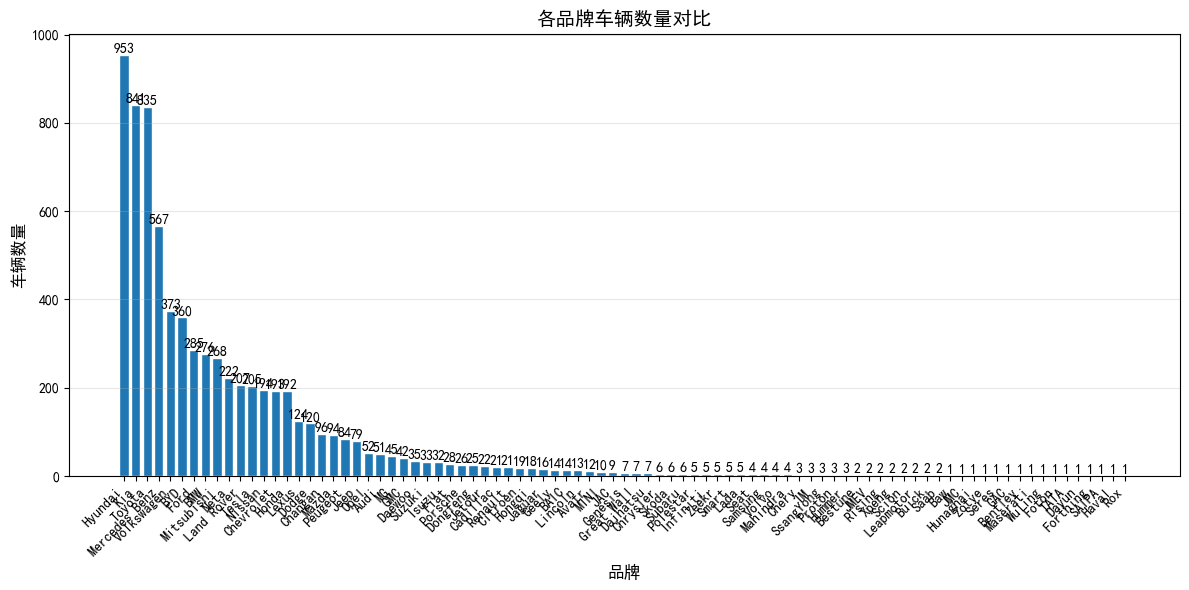

In [18]:
# 导入pandas库，用于数据统计与预处理
import pandas as pd
# 导入matplotlib的pyplot模块，核心绘图工具
import matplotlib.pyplot as plt
# 导入numpy库，用于数值计算与趋势线拟合
import numpy as np

# 全局设置：指定中文字体，解决中文显示乱码问题
plt.rcParams['font.sans-serif'] = ['SimHei']
# 全局设置：解决坐标轴负号显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False
# 全局设置：设置默认图表分辨率，提升显示清晰度
plt.rcParams['figure.dpi'] = 100
# 统计每个品牌的车辆数量，并按数量从高到低降序排序
brand_count = df['make'].value_counts().sort_values(ascending=False)
# 创建绘图画布，设置尺寸为12×6英寸
plt.figure(figsize=(12, 6))
# 绘制柱状图，x轴为品牌名称，y轴为对应车辆数量
plt.bar(brand_count.index, brand_count.values, edgecolor='white')
# 遍历每一根柱子，在顶部添加数值标签
for i, num in enumerate(brand_count.values):
    # 设置标签水平居中、垂直靠下，字号10
    plt.text(i, num, num, ha='center', va='bottom', fontsize=10)
# 设置图表主标题，字号14
plt.title('各品牌车辆数量对比', fontsize=14)
# 设置x轴标签
plt.xlabel('品牌', fontsize=12)
# 设置y轴标签
plt.ylabel('车辆数量', fontsize=12)
# x轴标签旋转45度并右对齐，避免文字重叠
plt.xticks(rotation=45, ha='right')
# 添加y轴方向网格线，降低透明度提升可读性
plt.grid(axis='y', alpha=0.3)
# 自动调整布局，防止标签被画布边缘截断
plt.tight_layout()
# 可选：将图表保存为本地图片，分辨率300dpi
# plt.savefig('图表1_品牌车辆数量.png', dpi=300, bbox_inches='tight')
# 显示绘制完成的图表
plt.show()

#### 结论各品牌车辆差异显著主要集中在Hyuandai Toyata等知名车企中

### 图表 2：不同车身类型的平均价格对比（柱状图）

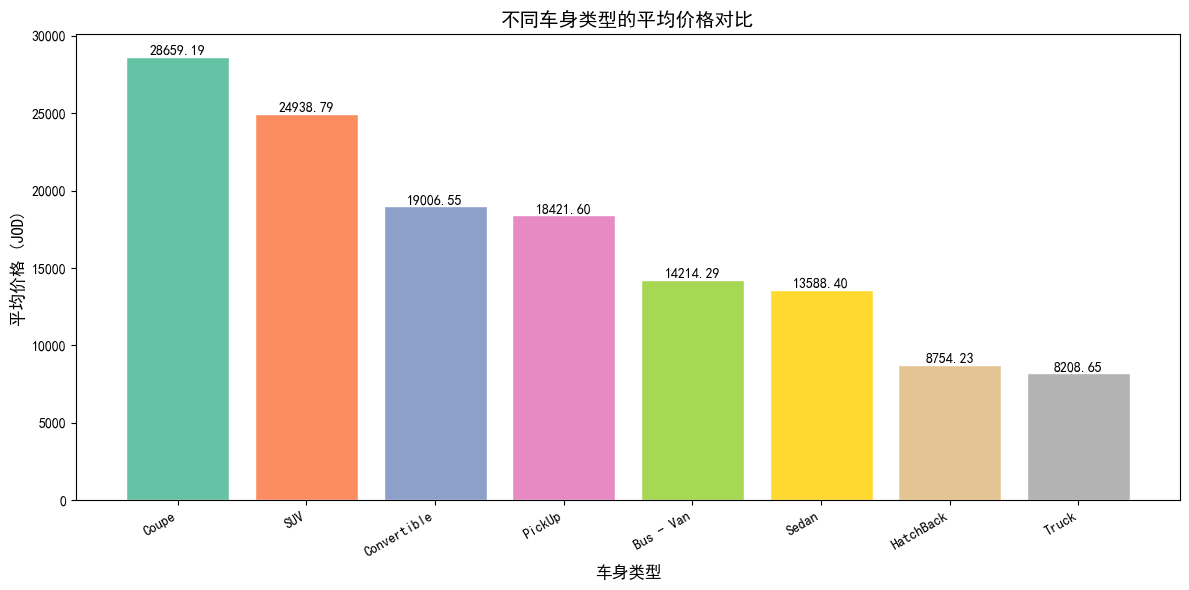

In [20]:
# 按车身类型分组，计算每组的平均价格，并按均价降序排序
avg_price_body = df.groupby('body_type')['price_value_JOD'].mean().sort_values(ascending=False)
# 创建绘图画布
plt.figure(figsize=(12, 6))
# 使用Set2配色方案生成与类别数量匹配的颜色列表
colors = plt.cm.Set2(range(len(avg_price_body)))
# 绘制柱状图，每个车身类型对应不同颜色
bars = plt.bar(avg_price_body.index, avg_price_body.values, color=colors, edgecolor='white')
# 遍历每根柱子，添加均价数值标签（保留2位小数）
for bar in bars:
    # 获取柱子高度（即均价数值）
    height = bar.get_height()
    # 在柱子顶部居中位置标注价格
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom', fontsize=10)
# 设置图表标题
plt.title('不同车身类型的平均价格对比', fontsize=14)
# 设置x轴标签
plt.xlabel('车身类型', fontsize=12)
# 设置y轴标签
plt.ylabel('平均价格 (JOD)', fontsize=12)
# x轴标签旋转30度
plt.xticks(rotation=30, ha='right')
# 自动调整布局
plt.tight_layout()
# 可选：保存图片
# plt.savefig('图表3_车身类型平均价格.png', dpi=300, bbox_inches='tight')
# 显示图表
plt.show()

#### 结论如图所示coupe SUV车身类型的平均价格远高于Sedan，价格更高

### 图表 4：车辆里程对价格所示（散点图）

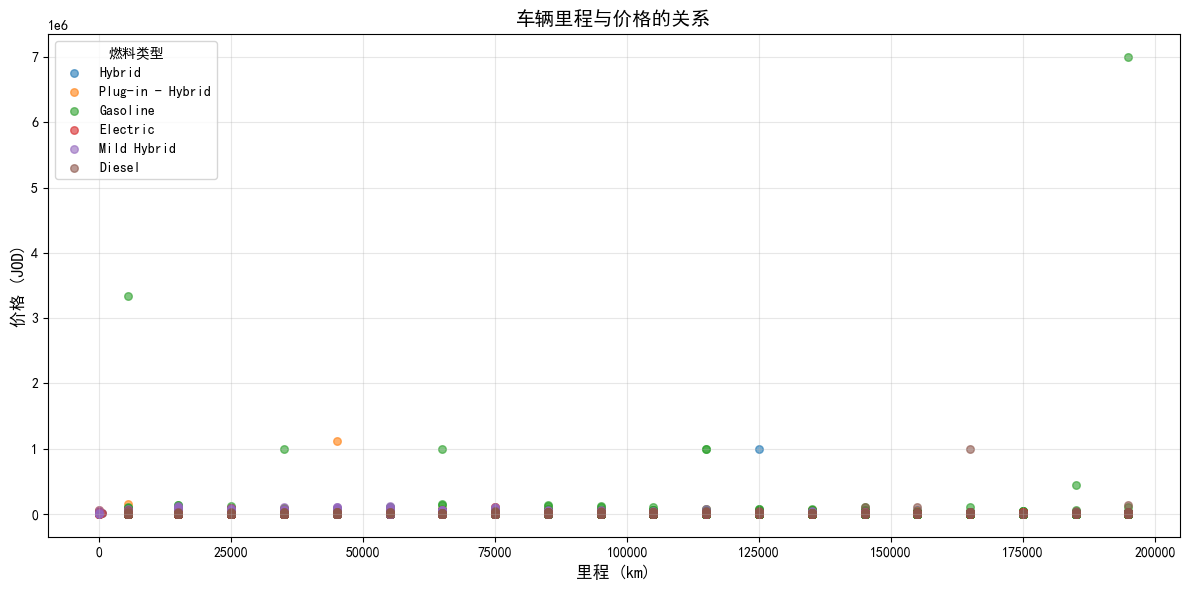

In [21]:
# 获取数据中所有不重复的燃料类型
fuel_types = df['fuel_type'].unique()
# 创建绘图画布
plt.figure(figsize=(12, 6))
# 遍历每种燃料类型，分别绘制散点以实现颜色区分
for fuel in fuel_types:
    # 筛选出当前燃料类型对应的子集数据
    subset = df[df['fuel_type'] == fuel]
    # 绘制散点图：点大小30，透明度0.6，添加图例标签
    plt.scatter(subset['mileage_km'], subset['price_value_JOD'], 
                s=30, alpha=0.6, label=fuel)
# 设置图表标题
plt.title('车辆里程与价格的关系', fontsize=14)
# 设置x轴标签
plt.xlabel('里程 (km)', fontsize=12)
# 设置y轴标签
plt.ylabel('价格 (JOD)', fontsize=12)
# 显示图例，并添加图例标题
plt.legend(title='燃料类型')
# 添加全局网格线
plt.grid(alpha=0.3)
# 自动调整布局
plt.tight_layout()
# 可选：保存图片
# plt.savefig('图表4_里程与价格散点图.png', dpi=300, bbox_inches='tight')
# 显示图表
plt.show()

### 结论：车辆里程对价格所示（散点图）来看由于极端豪车的情况来看，高价车不怎么受到车辆里程的影响，里程和燃料类型直观来看并不容易看出为此下图剔除了极端值车辆看中低档车的具体情况

图表 5 - 车龄与价格的关系（散点图 + 趋势线）(剔除了高价豪车阈值为4*10^5)溢价

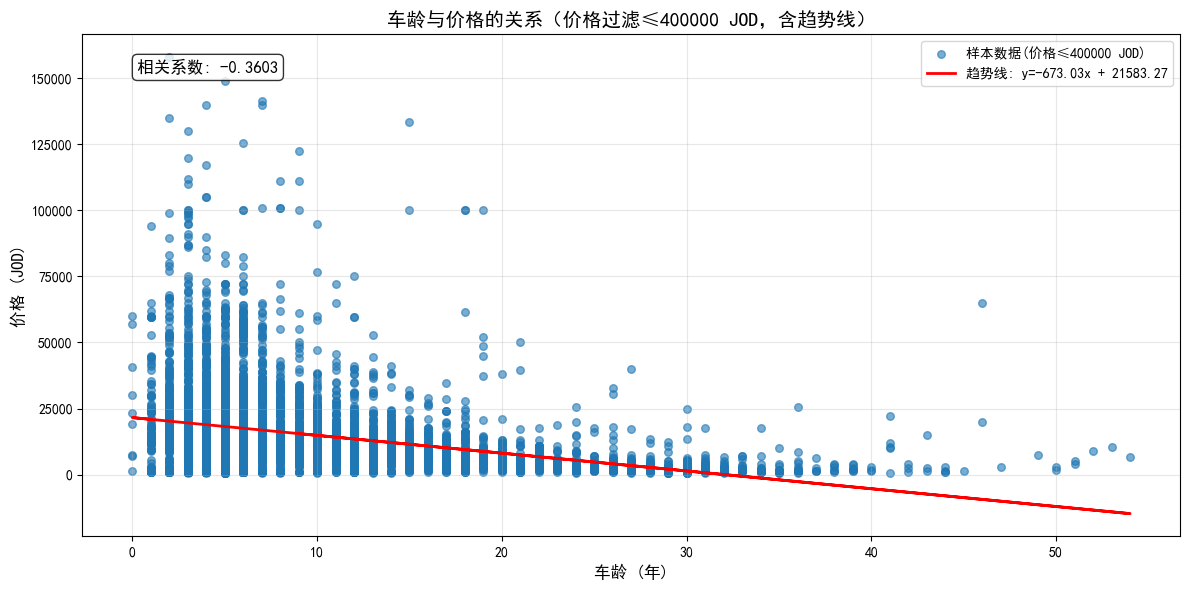

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ========== 核心清洗步骤 ==========
# 选取所需两列
data_clean = df[['car_age', 'price_value_JOD']].copy()
# 1. 无穷值转NaN并删除缺失行
data_clean = data_clean.replace([np.inf, -np.inf], np.nan).dropna()
# 2. 新增过滤：剔除价格大于4*10^5的车辆
threshold = 4 * (10 ** 5)
data_clean = data_clean[data_clean['price_value_JOD'] <= threshold]

# 校验样本数量
if len(data_clean) < 2:
    raise ValueError("清洗后有效样本不足2条，无法拟合趋势线")

x = data_clean['car_age']
y = data_clean['price_value_JOD']

# 校验x是否全部相同（奇异矩阵判断）
if x.nunique() == 1:
    print("警告：所有车龄数值完全一致，无法线性拟合，仅绘制散点图")
    plt.figure(figsize=(12, 6))
    plt.scatter(x, y, s=30, alpha=0.6, label='样本数据')
    plt.title('车龄与价格的关系（无趋势线，X无变化）', fontsize=14)
    plt.xlabel('车龄 (年)', fontsize=12)
    plt.ylabel('价格 (JOD)', fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    # 正常拟合流程
    plt.figure(figsize=(12, 6))
    plt.scatter(x, y, s=30, alpha=0.6, label='样本数据(价格≤400000 JOD)')
    
    # 一阶线性拟合
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    
    # 绘制趋势线
    plt.plot(x, p(x), color='red', linewidth=2, label=f'趋势线: y={z[0]:.2f}x + {z[1]:.2f}')
    
    # 相关系数
    corr = np.corrcoef(x, y)[0, 1]
    plt.text(0.05, 0.95, f'相关系数: {corr:.4f}', 
             transform=plt.gca().transAxes, 
             fontsize=12, 
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.title('车龄与价格的关系（价格过滤≤400000 JOD，含趋势线）', fontsize=14)
    plt.xlabel('车龄 (年)', fontsize=12)
    plt.ylabel('价格 (JOD)', fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### 结论车龄与价格的关系(剔除了高价豪车阈值为4*10^5)，明显看出车龄与价格是负相关的

C:\Users\11341\AppData\Local\Temp\ipykernel_26632\494646012.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=valid_brands, patch_artist=True)


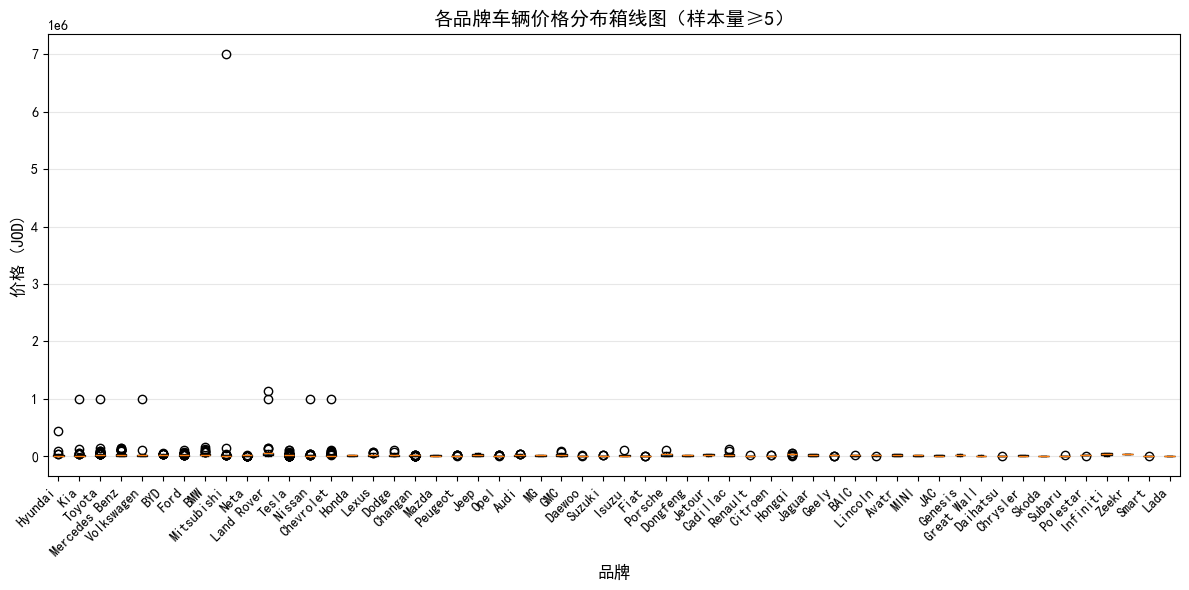

In [27]:
# 统计每个品牌的车辆样本数量
brand_counts = df['make'].value_counts()
# 筛选出样本量大于等于5的品牌
valid_brands = brand_counts[brand_counts >= 5].index
# 筛选出符合条件的品牌对应的数据子集
filtered_df = df[df['make'].isin(valid_brands)]
# 生成箱线图所需数据格式：每个品牌对应一个价格列表
box_data = [filtered_df[filtered_df['make'] == brand]['price_value_JOD'] for brand in valid_brands]
# 创建绘图画布
plt.figure(figsize=(12, 6))
# 绘制箱线图，启用填充色模式，设置品牌名称为x轴标签
plt.boxplot(box_data, labels=valid_brands, patch_artist=True)
# x轴标签旋转45度并右对齐，避免品牌名称重叠
plt.xticks(rotation=45, ha='right')
# 设置图表标题
plt.title('各品牌车辆价格分布箱线图（样本量≥5）', fontsize=14)
# 设置x轴标签
plt.xlabel('品牌', fontsize=12)
# 设置y轴标签
plt.ylabel('价格 (JOD)', fontsize=12)
# 添加y轴网格线
plt.grid(axis='y', alpha=0.3)
# 自动调整布局
plt.tight_layout()
# 可选：保存图片
# plt.savefig('图表6_品牌价格箱线图.png', dpi=300, bbox_inches='tight')
# 显示图表
plt.show()

单元格 7：图表 6 - 各品牌价格分布（箱线图），为求直观依旧剔除价格大于5*10^5JOD的车辆

C:\Users\11341\AppData\Local\Temp\ipykernel_26632\4178982525.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=valid_brands, patch_artist=True)


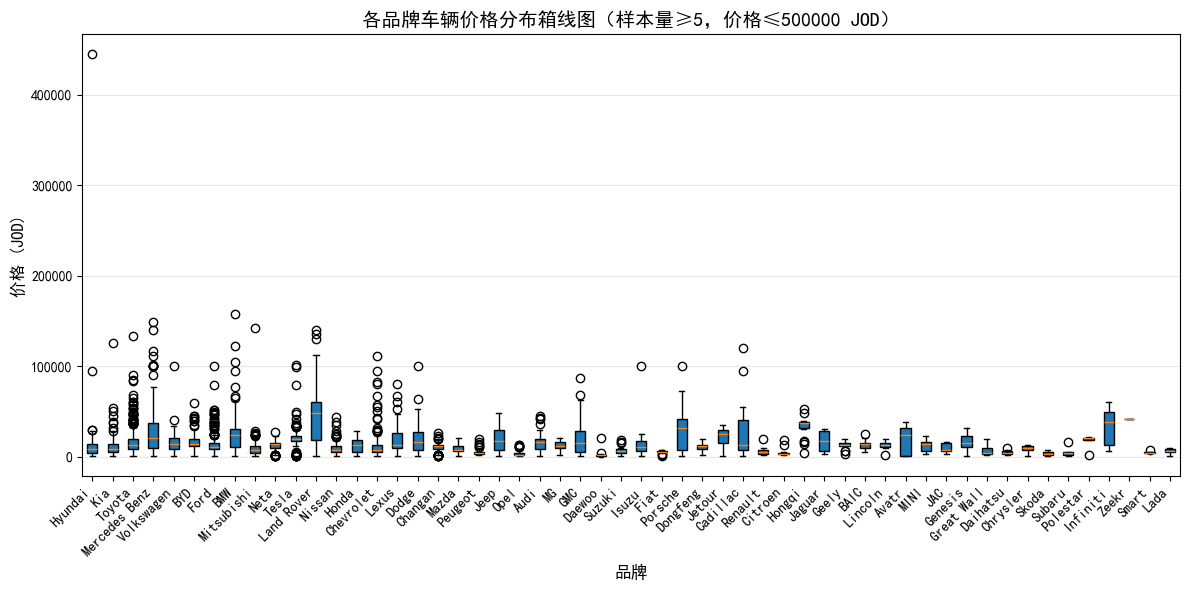

清洗前总有效数据：7253
剔除50万以上豪车后数据量：7244
筛选后保留品牌数量：54
各品牌样本数：
 make
Hyundai          953
Kia              840
Toyota           834
Mercedes Benz    567
Volkswagen       372
BYD              360
Ford             285
BMW              276
Mitsubishi       267
Neta             222
Tesla            205
Land Rover       205
Nissan           193
Honda            192
Chevrolet        192
Lexus            124
Dodge            120
Changan           96
Mazda             94
Peugeot           84
Jeep              79
Opel              52
Audi              51
MG                45
GMC               42
Daewoo            35
Suzuki            33
Isuzu             32
Fiat              28
Porsche           26
Dongfeng          25
Jetour            22
Cadillac          21
Renault           21
Citroen           19
Hongqi            18
Jaguar            16
Geely             14
BAIC              14
Lincoln           13
Avatr             12
MINI              10
JAC                9
Genesis            7
Great Wall      

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. 基础清洗：去缺失、无穷值 + 剔除价格大于50万JOD豪车
df_clean = df.copy()
# 无穷转NaN再删除空值
df_clean = df_clean.replace([np.inf, -np.inf], np.nan).dropna(subset=['make', 'price_value_JOD'])
# 过滤高价：只保留价格 ≤ 5*10^5
price_limit = 5 * 10**5
df_clean = df_clean[df_clean['price_value_JOD'] <= price_limit]

# 2. 筛选样本量≥5的品牌
brand_counts = df_clean['make'].value_counts()
valid_brands = brand_counts[brand_counts >= 5].index
filtered_df = df_clean[df_clean['make'].isin(valid_brands)]

# 3. 构造箱线图数据
box_data = [filtered_df[filtered_df['make'] == brand]['price_value_JOD'] for brand in valid_brands]

# 4. 绘图
plt.figure(figsize=(12, 6))
plt.boxplot(box_data, labels=valid_brands, patch_artist=True)
plt.xticks(rotation=45, ha='right')
plt.title('各品牌车辆价格分布箱线图（样本量≥5，价格≤500000 JOD）', fontsize=14)
plt.xlabel('品牌', fontsize=12)
plt.ylabel('价格 (JOD)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 可选：打印数据统计信息
print(f"清洗前总有效数据：{len(df.dropna(subset=['make','price_value_JOD']))}")
print(f"剔除50万以上豪车后数据量：{len(df_clean)}")
print(f"筛选后保留品牌数量：{len(valid_brands)}")
print("各品牌样本数：\n", brand_counts[brand_counts >= 5])

## 8. 影响价格因素的探究，结论已写在代码中

In [47]:
# 导入pandas库，用于数据清洗、分组统计与交叉表计算
import pandas as pd
# 导入numpy库，用于数值计算与基础统计
import numpy as np
# 导入scipy的独立样本t检验函数，用于显著性差异检验（numpy无内置t检验，采用科学计算标准库实现）
from scipy.stats import ttest_ind
# 读取路径与之前的代码保持一致，utf-8-sig编码保证中文正常显示
final_data_path = r"D:\HuaweiMoveData\Users\11341\Desktop\无权限\数据分析与可视化考试\cars_jordan_final.csv"
df = pd.read_csv(final_data_path, encoding='utf-8-sig')


In [44]:
# ========== 第一步：诊断并清洗 seats 列 ==========
# 查看 seats 列的所有唯一取值，确认所有文本类内容
print('seats列原始唯一值：')
print(df['seats'].unique())

# 定义映射规则：将文本座位数转为数值
# 'More than 9' 代表9座以上，统一映射为10；可根据实际数据补充其他映射
seat_mapping = {
    'More than 9': 10
}

# 执行映射替换
df['seats'] = df['seats'].replace(seat_mapping)
# 将列强制转为数值型，无法转换的异常值自动设为空值NaN
df['seats'] = pd.to_numeric(df['seats'], errors='coerce')

# 打印转换后状态，确认转换成功
print('\n转换后seats列数据类型：', df['seats'].dtype)
print('转换后seats列空值数量：', df['seats'].isna().sum())

# ========== 第二步：计算相关系数矩阵 ==========
# 指定参与相关性分析的数值字段
numeric_features = ['price_value_JOD', 'year', 'mileage_km', 'car_age', 'seats']
# 计算皮尔逊相关系数矩阵，自动忽略空值
corr_matrix = df[numeric_features].corr()

# 打印结果，保留4位小数提升可读性
print('\n===== 价格与数值变量的相关系数矩阵 =====')
print(corr_matrix.round(4))


#分组分析不同特征对价格的影响
# ========== 1. 漆面状况对价格的影响 ==========
# 按漆面状况分组，统计每组的车辆数量、平均价格、价格中位数，按均价降序排序
paint_analysis = df.groupby('feat_paintcondition')['price_value_JOD'].agg(
    车辆数量='count',
    平均价格='mean',
    价格中位数='median'
).sort_values('平均价格', ascending=False)
print('===== 不同漆面状况的价格统计 =====')
print(paint_analysis.round(2))

# ========== 2. 保险情况对价格的影响 ==========
# 按保险情况分组，计算价格相关统计指标
insurance_analysis = df.groupby('feat_insurance')['price_value_JOD'].agg(
    车辆数量='count',
    平均价格='mean',
    价格中位数='median'
).sort_values('平均价格', ascending=False)
print('\n===== 不同保险情况的价格统计 =====')
print(insurance_analysis.round(2))

# ========== 3. 车身颜色对价格的影响（仅保留样本量≥3的颜色） ==========
# 先统计每个颜色的车辆数量
color_counts = df['color'].value_counts()
# 筛选出车辆数量大于等于3的颜色
valid_colors = color_counts[color_counts >= 3].index
# 过滤出符合条件的颜色对应的数据子集
color_filtered = df[df['color'].isin(valid_colors)]
# 按颜色分组计算价格统计指标
color_analysis = color_filtered.groupby('color')['price_value_JOD'].agg(
    车辆数量='count',
    平均价格='mean',
    价格中位数='median'
).sort_values('平均价格', ascending=False)
print('\n===== 不同车身颜色的价格统计（样本量≥3） =====')
print(color_analysis.round(2))
#
# 计算价格的25%、50%、75%分位数，作为分箱边界
q25 = df['price_value_JOD'].quantile(0.25)
q50 = df['price_value_JOD'].quantile(0.5)
q75 = df['price_value_JOD'].quantile(0.75)

# 打印分位数结果便于核对
print(f'价格四分位数：\n25%分位：{q25:.2f}\n50%分位（中位数）：{q50:.2f}\n75%分位：{q75:.2f}')

# 使用pd.cut进行价格分箱，创建分类变量price_category
# 规则：低价(<25%分位)、中低价(25%-50%)、中高价(50%-75%)、高价(>75%)
# right=False 表示区间左闭右开，即边界值归入更高一档
df['price_category'] = pd.cut(
    df['price_value_JOD'],
    bins=[-float('inf'), q25, q50, q75, float('inf')],
    labels=['低价', '中低价', '中高价', '高价'],
    right=False
)

# 统计各价格类别的数量与占比
category_stats = pd.DataFrame({
    '车辆数量': df['price_category'].value_counts().sort_index(),
    '占比(%)': df['price_category'].value_counts(normalize=True).sort_index().round(4) * 100
})
print('\n===== 各价格类别分布 规则：低价(<25%分位)、中低价(25%-50%)、中高价(50%-75%)、高价(>75%) =====')
print(category_stats)

# 生成价格类别与燃料类型的计数交叉表
cross_count = pd.crosstab(df['price_category'], df['fuel_type'])
# 生成行百分比交叉表：每行总和为100%，查看不同价格档位下燃料类型的占比
cross_pct = pd.crosstab(
    df['price_category'], 
    df['fuel_type'], 
    normalize='index'  # 按行归一化
).round(4) * 100

print('===== 价格类别 × 燃料类型 交叉表（车辆数量） =====')
print(cross_count)
print('\n===== 价格类别 × 燃料类型 交叉表（行百分比%） =====')
print(cross_pct.round(2))
#单元格 6：计算性价比并输出 Top20
# 先过滤掉里程为0或价格为0的异常数据，避免除以0报错
cp_df = df[(df['mileage_km'] > 0) & (df['price_value_JOD'] > 0)].copy()

# 按公式计算性价比指数：性价比 = (2026 - 生产年份) * 100000 / 里程 / 价格
# 公式逻辑：车龄越新、里程越低、价格越低，性价比数值越高
cp_df['cost_performance'] = (2026 - cp_df['year']) * 100000 / cp_df['mileage_km'] / cp_df['price_value_JOD']

# 按性价比降序排序，取前20名，选取核心字段展示
top20_cp = cp_df.sort_values('cost_performance', ascending=False).head(20)[
    ['make', 'year', 'mileage_km', 'price_value_JOD', 'cost_performance']
]
# 重命名列名，优化输出可读性
top20_cp.columns = ['品牌', '生产年份', '里程(km)', '价格(JOD)', '性价比指数']

print('===== 性价比最高的Top20车辆 =====')
print(top20_cp.round(2))

#
# ========== 1. 电动车 vs 燃油车 价格差异检验 ==========
# 筛选电动车组的价格数据，剔除空值
electric_prices = df[df['fuel_type'] == 'Electric']['price_value_JOD'].dropna()
# 筛选燃油车组的价格数据，剔除空值
gasoline_prices = df[df['fuel_type'] == 'Gasoline']['price_value_JOD'].dropna()

print('===== 电动车 vs 燃油车 价格差异t检验 =====')
print(f'电动车样本量：{len(electric_prices)}，燃油车样本量：{len(gasoline_prices)}')

# 两组样本量均≥2时才执行检验，避免报错
if len(electric_prices) >= 2 and len(gasoline_prices) >= 2:
    # 执行Welch's t检验（不假设两组方差相等，更稳健）
    t_stat, p_value = ttest_ind(electric_prices, gasoline_prices, equal_var=False)
    print(f't统计量：{t_stat:.4f}，p值：{p_value:.4f}')
    # 基于95%置信水平做显著性判断
    if p_value < 0.05:
        print('结论：在95%置信水平下，电动车与燃油车的价格存在显著差异')
    else:
        print('结论：在95%置信水平下，电动车与燃油车的价格无统计学显著差异')
else:
    print('样本量不足，无法执行t检验')

print('-' * 50)

# ========== 2. 新车 vs 旧车 价格差异检验 ==========
# 定义划分规则：车龄≤1年为准新车，车龄>1年为旧车（可根据业务场景调整阈值）
new_car_prices = df[df['car_age'] <= 1]['price_value_JOD'].dropna()
old_car_prices = df[df['car_age'] > 1]['price_value_JOD'].dropna()

print('===== 新车 vs 旧车 价格差异t检验 =====')
print(f'新车（车龄≤1年）样本量：{len(new_car_prices)}，旧车样本量：{len(old_car_prices)}')

if len(new_car_prices) >= 2 and len(old_car_prices) >= 2:
    t_stat2, p_value2 = ttest_ind(new_car_prices, old_car_prices, equal_var=False)
    print(f't统计量：{t_stat2:.4f}，p值：{p_value2:.4f}')
    if p_value2 < 0.05:
        print('结论：在95%置信水平下，新车与旧车的价格存在显著差异')
    else:
        print('结论：在95%置信水平下，新车与旧车的价格无统计学显著差异')
else:
    print('样本量不足，无法执行t检验')

seats列原始唯一值：
[ 5  4  7  6  2  3  8 10  9]

转换后seats列数据类型： int64
转换后seats列空值数量： 0

===== 价格与数值变量的相关系数矩阵 =====
                 price_value_JOD    year  mileage_km  car_age   seats
price_value_JOD           1.0000  0.0390     -0.0199  -0.0390  0.0321
year                      0.0390  1.0000     -0.3306  -1.0000  0.1172
mileage_km               -0.0199 -0.3306      1.0000   0.3306 -0.0034
car_age                  -0.0390 -1.0000      0.3306   1.0000 -0.1172
seats                     0.0321  0.1172     -0.0034  -0.1172  1.0000
===== 不同漆面状况的价格统计 =====
                     车辆数量      平均价格    价格中位数
feat_paintcondition                         
Original Paint       4627  18937.90  13200.0
Total repaint         733  18607.31   6000.0
Partially repainted   866  13291.49  10800.0
Other                1027  12169.15   8700.0

===== 不同保险情况的价格统计 =====
                         车辆数量      平均价格    价格中位数
feat_insurance                                  
Not Insured               389  35857.98  10500.0
Compr

## 8. 主要结论
1. 该车身颜色以黑与白受消费者喜爱，此平台上的二手车辆显著多与新车，保险等级越高的车辆其平均价格也越高，Opel与Daewoo的性价比最高建议购买结论。
2. 新车vs旧车通过t检验得到，新车与旧车价格有明显差异，而电动车和燃油车并没有支持。
3. 数据本身有数据不完整，通过平均数或众数填充，在如判断品牌对价格的影响的时候，部分品牌样本量过小直接剔除。